In [ ]:
import matplotlib.pyplot as plt
import sympy as sym
import numpy as np
from scipy.optimize import NonlinearConstraint, minimize
from functools import partial
from typing import Callable
from copy import copy

# Метод аддитивной свёртки

### **Идея метода аддитивной свёртки**  

**Суть:**  
Объединяем все целевые функции в **одну**, складывая их с весами:  
```
F(x) = w₁·f₁(x) + w₂·f₂(x) + ... + wₙ·fₙ(x)
```  
Где:  
- `f₁, f₂, ..., fₙ` — наши функции.  
- `w₁, w₂, ..., wₙ` — веса (какая функция важнее).  

**Как работает?**  
1. Выбираем веса.  
2. Оптимизируем **одну** функцию `F(x)` вместо множества.  
3. Получаем **компромиссное решение** — что-то среднее между всеми целями.  

**Плюс:**  
Простота — одна задача оптимизации вместо сложных многоэтапных расчётов.  

**Минус:**  
Если веса выбраны плохо или функции конфликтуют, решение может быть неоптимальным.  

**Вывод:**  
Метод для ленивых (в хорошем смысле!), когда нужно быстро получить разумный компромисс.

In [10]:
def merge(list1, list2) -> list[tuple]:
    return list(zip(list1, list2))

def generate_points():
    ls = []
    for i in range(10):
        for j in range(10 - i):
            ls.append([i / 10, j / 10, (10 - i - j) / 10])
    return np.array(ls)

def get_alfa_from_x_and_gradient(variables, f):
    N = len(variables)
    a = sym.symbols('a')
    s_vars = sym.symbols(' '.join([f's{i}' for i in range(1, N+1)]))
    
    replacement = [(var, var + a * s_vars[i]) for i, var in enumerate(variables)]
    gradients = [sym.diff(f, var).subs(replacement) for var in variables]
    
    # Добавляем регуляризацию
    epsilon = 1e-8
    numerator = sum(gradients[i] * s_vars[i] for i in range(N))
    denominator = sum((gradients[i] * s_vars[i]).diff(a) for i in range(N)) + epsilon
    
    solution = sym.solve(numerator, a)
    solution = solution[0] if solution else 0
    
    return sym.lambdify(variables + s_vars, solution, modules='numpy')

def get_func_gradient_from_point(variables, f, x0):
    gradients_f = [sym.diff(f, variable) for variable in variables]
    lambd_gradients_f = [sym.lambdify(variables, gradient_f) for gradient_f in gradients_f]
    grad_f_x = np.array([f(*x0) for f in lambd_gradients_f])
    return np.where(np.abs(grad_f_x) > 0.0001, grad_f_x, 0)

def steepest_descent(variables, f, x0, eps=1e-3, max_iter=1000):
    x = x0.copy()
    alpha_func = get_alfa_from_x_and_gradient(variables, f)
    
    for _ in range(max_iter):
        grad = get_func_gradient_from_point(variables, f, x)
        grad_norm = np.linalg.norm(grad)
        
        if grad_norm < eps:
            break
            
        # Добавляем защиту от нулевого направления
        if np.allclose(grad, 0):
            grad = np.random.normal(size=grad.shape) * eps
            
        try:
            alpha = alpha_func(*x, *(-grad))
            alpha = np.clip(alpha, 0, 1)  # Ограничиваем шаг
        except ZeroDivisionError:
            alpha = 0.1  # Значение по умолчанию при ошибке
            
        x_new = x + alpha * (-grad)
        
        if np.linalg.norm(x_new - x) < eps:
            break
            
        x = x_new
    
    return x

In [11]:
def additive_convolution(funcs: list[sym.Add], x0: np.ndarray, eps: float):
    N = len(funcs)
    alphas = sym.symbols(' '.join([f'alpha{i+1}' for i in range(N)]))
    f0 = sum([alphas[i] * funcs[i] for i in range(N)])
    num_alphas = generate_points()
    
    # Вычислим минимумы каждой функции
    minima = []
    for func in funcs:
        min_x = steepest_descent(variables, func, x0=np.array([0, 0]), eps=1e-5)
        minima.append(min_x)
    minima = np.array(minima)
    
    points = []
    colors = []
    for i in range(len(num_alphas)):
        func = f0.subs(merge(alphas, num_alphas[i]))
        point = steepest_descent(variables, func, x0=x0, eps=eps)
        points.append(point)
        
        # Вычисляем расстояния до каждого минимума
        distances = np.array([np.linalg.norm(point - min_p) for min_p in minima])
        
        # Избегаем деления на ноль (если точка совпадает с минимумом)
        distances = np.clip(distances, 1e-10, None)
        
        # Инвертируем расстояния (чем ближе к минимуму - тем больше вес)
        weights = 1.0 / distances
        
        # Нормализуем веса
        normalized_weights = weights / np.sum(weights)
        
        # Создаем цвет как взвешенную сумму RGB
        # f1: зеленый (0,1,0), f2: синий (0,0,1), f3: красный (1,0,0)
        color = np.array([
            normalized_weights[2],  # Красный (f3)
            normalized_weights[0],  # Зеленый (f1)
            normalized_weights[1]   # Синий (f2)
        ])
        
        # Увеличиваем насыщенность цвета
        color = color ** 0.3  # Гамма-коррекция для более ярких цветов
        colors.append(color)
    
    points = np.array(points)
    colors = np.array(colors)
    
    plt.figure(figsize=(12, 10))
    plt.scatter(points[:, 0], points[:, 1], c=colors, s=100, alpha=0.8, edgecolors='k', linewidths=0.5)
    
    # Добавляем маркеры для минимумов функций
    plt.scatter(minima[:, 0], minima[:, 1], c=['green', 'blue', 'red'], 
                marker='o', s=100, edgecolor='black', linewidth=1.5)
    
    # Легенда
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', label='Минимум f1 (зеленый)',
                  markerfacecolor='green', markersize=12),
        plt.Line2D([0], [0], marker='o', color='w', label='Минимум f2 (синий)',
                  markerfacecolor='blue', markersize=12),
        plt.Line2D([0], [0], marker='o', color='w', label='Минимум f3 (красный)',
                  markerfacecolor='red', markersize=12)
    ]
    plt.legend(handles=legend_elements, fontsize=12, loc='upper right')
    
    plt.title('Цветовая визуализация близости к минимумам функций', fontsize=14)
    plt.xlabel('x1', fontsize=12)
    plt.ylabel('x2', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    plt.show()

Функции для оптимизации:


0.5*x1*x2 + (x1 - 2)**2 + (x2 - 3)**2

-x1*x2 + 3*x2**2 + 2*(x1 + 1)**2

0.8*x1*x2 + 0.5*(x1 - 4)**2 + 2*(x2 + 2)**2


Оптимизация с начальной точкой (0, 0):


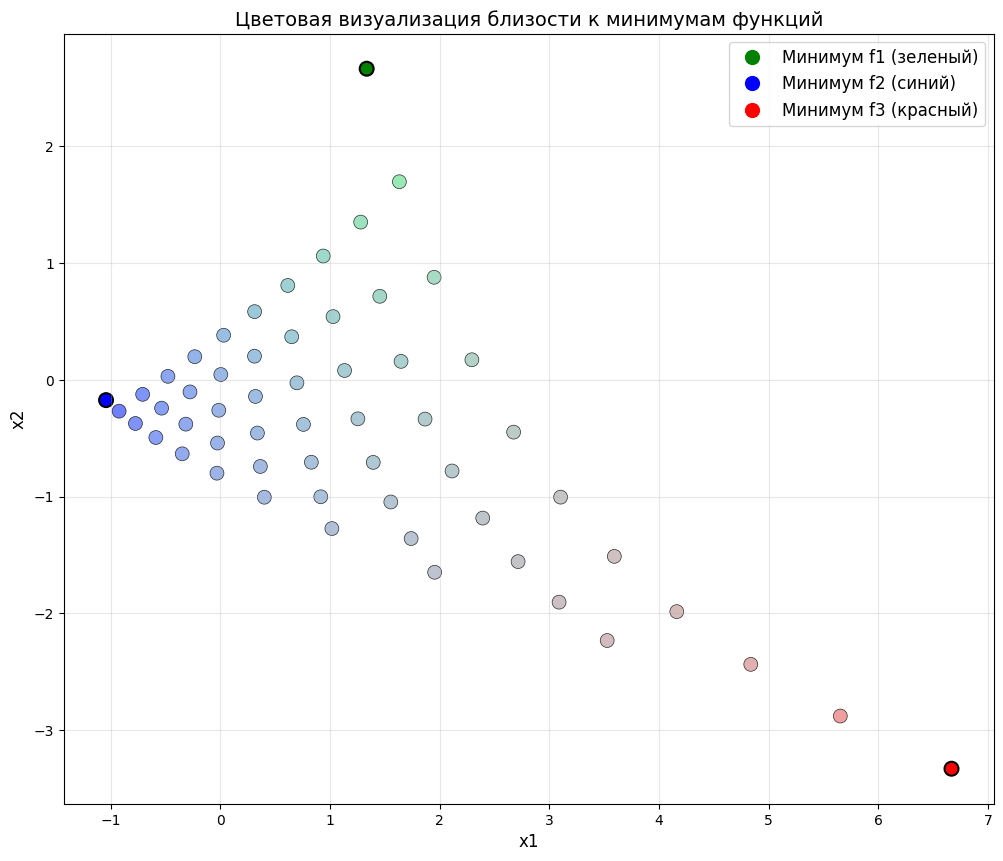

In [12]:
# Инициализация символьных переменных
variables = x1, x2 = sym.symbols('x1, x2')
coeffs = sym.symbols('a, b, c, d, e')

# Определение функции
f = coeffs[0]*(x1 - coeffs[1])**2 + coeffs[2]*(x2 - coeffs[3])**2 + coeffs[4]*x1*x2

# Значения коэффициентов
values_of_coeffs = [
    [1, 2, 1, 3, 0.5],
    [2, -1, 3, 0, -1],
    [0.5, 4, 2, -2, 0.8]
]

funcs = [f.subs(dict(zip(coeffs, value))) for value in values_of_coeffs]

print("Функции для оптимизации:")
for func in funcs:
    display(func)

print("\nОптимизация с начальной точкой (0, 0):")
additive_convolution(funcs, np.array([0.0, 0.0]), 1e-3)

# Дискриминационный метод

### **Идея дискриминационного метода**  

**Суть:**  
Выбираем **главную цель**, а остальные превращаем в **ограничения**:  
```
Минимизировать: f₁(x)  
При условиях:  
f₂(x) ≤ ε₂  (например, вес ≤ 10 кг)  
f₃(x) ≤ ε₃  (например, время ≤ 24 часа)  
```  
Где:  
- `f₁` — наша главная цель.  
- `f₂, f₃, ...` — второстепенные цели, которые не должны выходить за жёсткие рамки (`ε`).  

**Как работает?**  
1. Задаём **пределы** для второстепенных целей.  
2. Ищем лучшее решение **только для главной цели**, но так, чтобы остальные не "сломали" ограничения.  

**Плюс:**  
Жёсткий контроль над второстепенными параметрами — они точно не выйдут за заданные рамки.  

**Минус:**  
Нужно заранее знать, какие пределы (`ε`) разумны, иначе решение может не найтись.  

**Вывод:**  
Метод для тех, кто чётко знает:  
- Что для них **главное**.  
- Какие параметры **нельзя ухудшать** вообще.  

→ Даёт **точный результат без "усреднения"**, как в аддитивной свёртке.

In [13]:
def convolution(x0: list[float], alphas: list[float], funcs: list[Callable]) -> float:
    return sum([alpha * func(x0) for alpha, func in zip(alphas, funcs)])

def funcs_values_from_x(x, funcs):
    return [f(x) for f in funcs]

def generate_points():
    return [[i/10, j/10, (10-i-j)/10] for i in range(10) for j in range(10-i)]

In [14]:
def discriminatory_method(x0: list[float], funcs: Callable, concessions: list[float]):
    num_alphas = generate_points()
    pareto_points = []
    for alpha in num_alphas:
        F = partial(convolution, alphas=alpha, funcs=funcs)
        constraints = NonlinearConstraint(
            fun=partial(funcs_values_from_x, funcs=funcs),
            lb=-np.inf,
            ub=concessions
        )
        pareto_points.append(minimize(F, x0, constraints=constraints).x)
    return np.array(pareto_points)

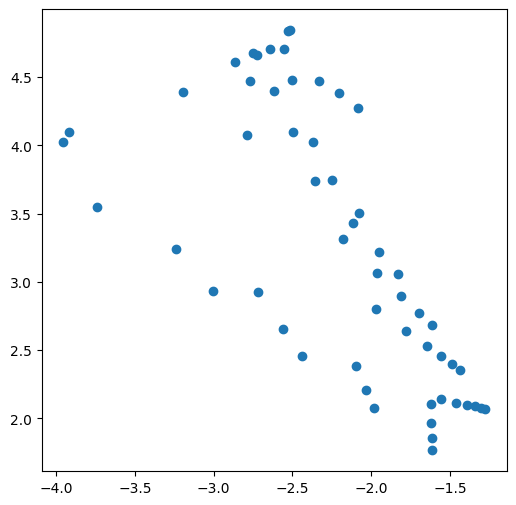

In [15]:
def f(x: list[float], coeffs: list[float]) -> float:
    return coeffs[0]*(x[0] - coeffs[1])**2 + coeffs[2]*(x[1] - coeffs[3])**2

f1 = partial(f, coeffs=[2,  6, 3,  6])
f2 = partial(f, coeffs=[3, -4, 1, -6])
f3 = partial(f, coeffs=[1, -7, 2,  8])
funcs = [f1, f2, f3]

points = discriminatory_method([0., 0.], funcs, [20, 30, 40])

plt.figure(figsize=(6, 6))
plt.scatter(points[:, 0], points[:, 1])
plt.show()

# Метод последовательных уступок

### **Идея метода последовательных уступок — просто и коротко**  

**Суть:**  
Оптимизируем цели **по очереди**, давая "послабления" на уже пройденные этапы:  
1. Сначала минимизируем **самую важную цель** → получаем `min f₁`.  
2. Затем минимизируем **вторую цель**, но разрешаем первой цели **чуть ухудшиться**:  
   ```  
   f₁(x) ≤ min f₁ + "уступка"
   ```  
3. Повторяем для остальных целей, добавляя новые ограничения.  

**Как работает?**  
- На каждом шаге **фиксируем прогресс** для предыдущих целей.  
- Новые цели оптимизируем **только в рамках уступок**, данных ранее.  

**Плюсы:**  
- Чёткий приоритет — каждая следующая цель не "ломает" предыдущие.  
- Гибкость — можно регулировать размер "уступок".  

**Минусы:**  
- Если первая цель выбрана неудачно, остальные будут подстраиваться плохо.  
- Жёсткие ограничения могут оставить мало вариантов для последних целей.  

**Вывод:**  
Метод для задач, где:  
- Есть **явный порядок важности** целей.  
- Нужно **постепенно** находить компромисс, не теряя достигнутого.  

→ Даёт **пошаговый контроль** над оптимизацией, но требует аккуратного выбора уступок.

In [16]:
def sequential_optimization(x0, funcs, concessions):
    constr = []
    points = []
    concessions += [0]
    x_ = x0
    
    for i in range(len(funcs)):
        min_x = minimize(funcs[i], x_, constraints=constr).x
        x_ = min_x
        func = copy(funcs[i])
        inequality = lambda x: func(x) - func(min_x)
        constr.append(
            {'type': 'ineq', 'fun': lambda x: -inequality(x) + concessions[i]}
        )
        points.append(min_x)
    return np.array(points)

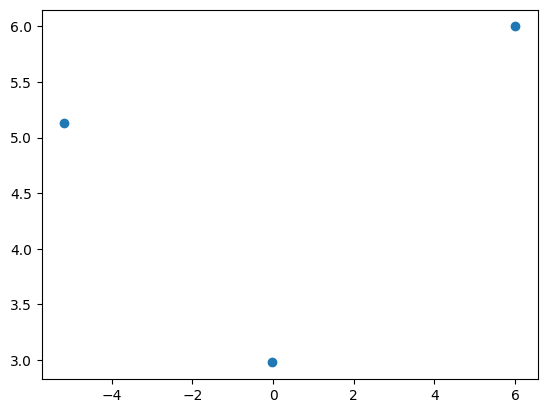

In [17]:
def f(x: list[float], coeffs: list[float]) -> float:
    return coeffs[0]*(x[0] - coeffs[1])**2 + coeffs[2]*(x[1] - coeffs[3])**2

f1 = partial(f, coeffs=[2,  6, 3,  6])
f2 = partial(f, coeffs=[3, -4, 1, -6])
f3 = partial(f, coeffs=[1, -7, 2,  8])
funcs = [f1, f2, f3]

x0 = [0., 0.]
concessions = [10, 100]

points = sequential_optimization(x0, funcs, concessions)

plt.scatter(points[:, 0], points[:, 1])
plt.show()